# Principal Component Analysis (PCA)

In [9]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load Iris dataset
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
X_iris = df_iris.copy()
target = iris.target
print("✓ Iris dataset loaded:", X_iris.shape)

✓ Iris dataset loaded: (150, 4)


In [10]:
# Preprocess & Standardize
X_iris = X_iris.fillna(X_iris.mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)
print("✓ Features standardized")

✓ Features standardized


In [11]:
# Apply PCA (all components)
pca_full = PCA()
pca_full.fit(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Create 2D & 3D PCA models
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print("✓ PCA applied")
print(f"2D: {cum_var[1]*100:.1f}% | 3D: {cum_var[2]*100:.1f}%")

✓ PCA applied
2D: 95.8% | 3D: 99.5%


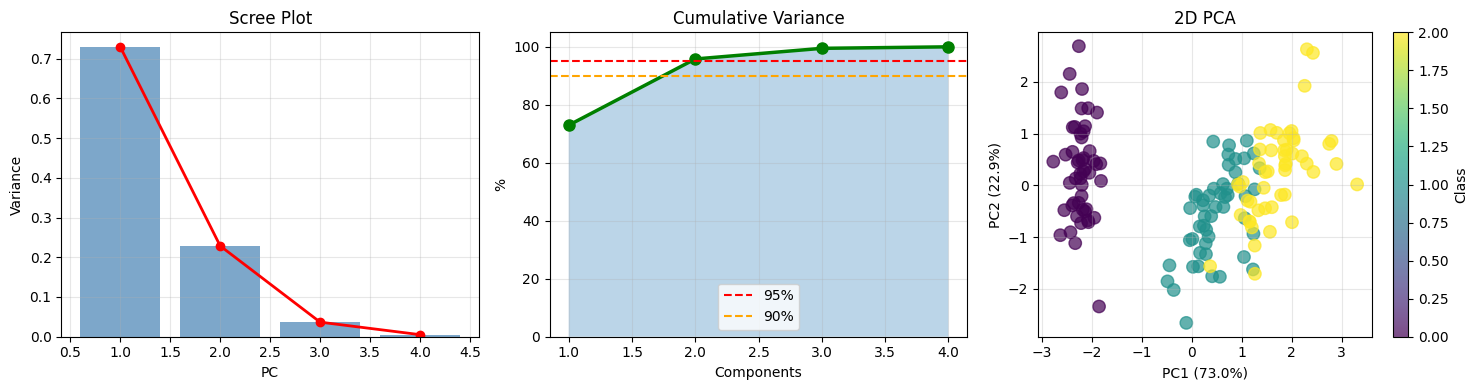

(None, None)

In [12]:
# Visualize: Scree + Cumulative Variance + 2D PCA
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Scree plot
ax[0].bar(range(1, 5), explained_var, color='steelblue', alpha=0.7)
ax[0].plot(range(1, 5), explained_var, 'ro-', linewidth=2)
ax[0].set_title('Scree Plot'), ax[0].set_xlabel('PC'), ax[0].set_ylabel('Variance')
ax[0].grid(True, alpha=0.3)

# Cumulative variance
ax[1].plot(range(1, 5), cum_var*100, 'go-', linewidth=2.5, markersize=8)
ax[1].axhline(y=95, color='red', linestyle='--', label='95%')
ax[1].axhline(y=90, color='orange', linestyle='--', label='90%')
ax[1].fill_between(range(1, 5), cum_var*100, alpha=0.3)
ax[1].set_title('Cumulative Variance'), ax[1].set_xlabel('Components'), ax[1].set_ylabel('%')
ax[1].legend(), ax[1].grid(True, alpha=0.3), ax[1].set_ylim([0, 105])

# 2D PCA scatter
scatter = ax[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=target, cmap='viridis', s=80, alpha=0.7)
ax[2].set_title('2D PCA'), ax[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)'), ax[2].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax[2], label='Class')
plt.tight_layout(), plt.show()

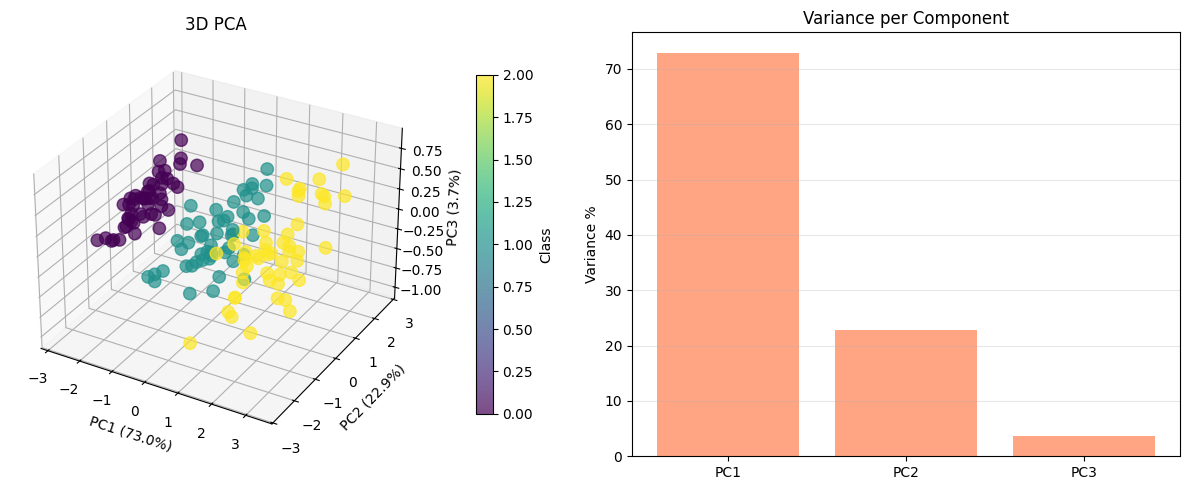

✓ 3D explained: 99.5%


In [13]:
# 3D PCA Visualization
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
scatter_3d = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=target, cmap='viridis', s=80, alpha=0.7)
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)'), ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)'), ax1.set_title('3D PCA')
plt.colorbar(scatter_3d, ax=ax1, pad=0.1, shrink=0.8, label='Class')

# Variance comparison
ax2 = fig.add_subplot(1, 2, 2)
ax2.bar(['PC1', 'PC2', 'PC3'], [cum_var[0]*100, cum_var[1]*100-cum_var[0]*100, cum_var[2]*100-cum_var[1]*100], color='coral', alpha=0.7)
ax2.set_title('Variance per Component'), ax2.set_ylabel('Variance %'), ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout(), plt.show()
print(f"✓ 3D explained: {cum_var[2]*100:.1f}%")

In [14]:
# Quick Summary - Iris
print("="*50)
print("IRIS ANALYSIS")
print("="*50)
print(f"Original features: {X_iris.shape[1]}")
print(f"PC1 variance: {explained_var[0]*100:.2f}%")
print(f"PC1-PC2 variance: {cum_var[1]*100:.2f}%")
print(f"PC1-PC3 variance: {cum_var[2]*100:.2f}%")
print(f"Dimensionality: 4 → 2 dims ({cum_var[1]*100:.1f}% retained)")

IRIS ANALYSIS
Original features: 4
PC1 variance: 72.96%
PC1-PC2 variance: 95.81%
PC1-PC3 variance: 99.48%
Dimensionality: 4 → 2 dims (95.8% retained)


In [15]:
# SCENARIO 2: Wine Dataset
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
X_wine_scaled = StandardScaler().fit_transform(X_wine)

pca_wine = PCA()
pca_wine.fit(X_wine_scaled)
exp_var_wine = pca_wine.explained_variance_ratio_
cum_var_wine = np.cumsum(exp_var_wine)

pca_wine_2d = PCA(n_components=2).fit_transform(X_wine_scaled)
pca_wine_3d = PCA(n_components=3).fit_transform(X_wine_scaled)

print("\n" + "="*50)
print("WINE ANALYSIS (13 features)")
print("="*50)
print(f"PC1 variance: {exp_var_wine[0]*100:.2f}%")
print(f"PC1-PC2 variance: {cum_var_wine[1]*100:.2f}%")
print(f"PC1-PC3 variance: {cum_var_wine[2]*100:.2f}%")
print(f"Dimensionality: 13 → 2 dims ({cum_var_wine[1]*100:.1f}% retained)")


WINE ANALYSIS (13 features)
PC1 variance: 36.20%
PC1-PC2 variance: 55.41%
PC1-PC3 variance: 66.53%
Dimensionality: 13 → 2 dims (55.4% retained)


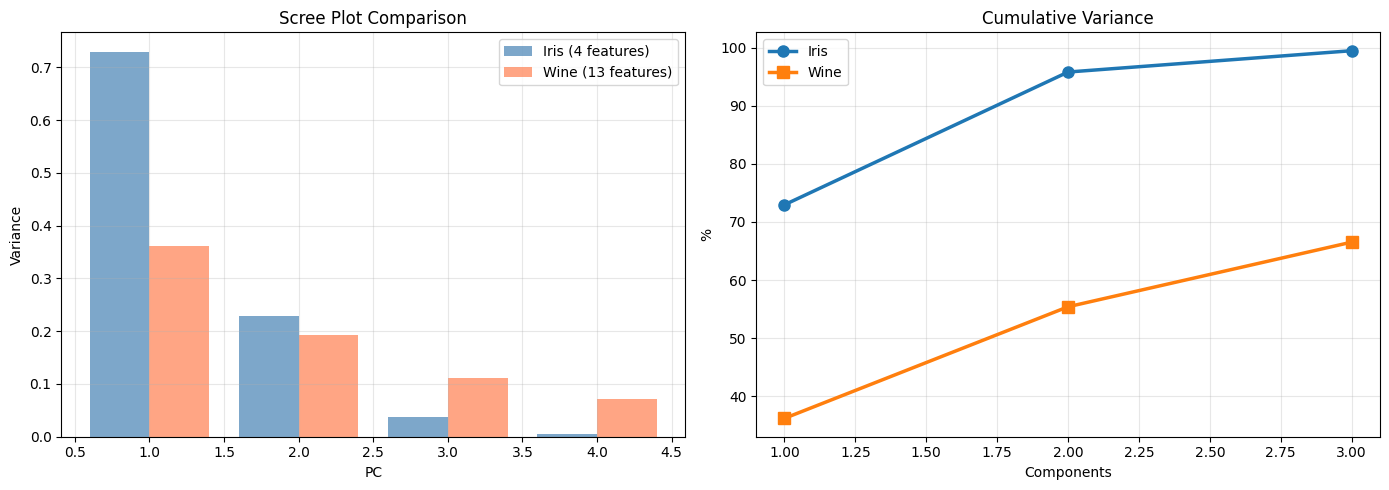


✓ Comparison: Iris captures more variance in fewer components (4 features)
✓ Wine needs more components (13 features, higher dimensionality)


In [17]:
# Wine Visualizations: Compare Iris vs Wine
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Scree plots comparison
ax[0].bar(np.arange(1, 5)-0.2, explained_var, width=0.4, label='Iris (4 features)', color='steelblue', alpha=0.7)
ax[0].bar(np.arange(1, 5)+0.2, exp_var_wine[:4], width=0.4, label='Wine (13 features)', color='coral', alpha=0.7)
ax[0].set_title('Scree Plot Comparison'), ax[0].set_xlabel('PC'), ax[0].set_ylabel('Variance'), ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Cumulative variance comparison
ax[1].plot(range(1, 4), cum_var[:3]*100, 'o-', linewidth=2.5, markersize=8, label='Iris')
ax[1].plot(range(1, 4), cum_var_wine[:3]*100, 's-', linewidth=2.5, markersize=8, label='Wine')
ax[1].set_title('Cumulative Variance'), ax[1].set_xlabel('Components'), ax[1].set_ylabel('%')
ax[1].legend(), ax[1].grid(True, alpha=0.3)

plt.tight_layout(), plt.show()

print("\n✓ Comparison: Iris captures more variance in fewer components (4 features)")
print("✓ Wine needs more components (13 features, higher dimensionality)")

In [18]:
# Final Comparison Table
comparison = pd.DataFrame({
    'Dataset': ['Iris', 'Wine'],
    'Features': [4, 13],
    'PC1 (%)': [f"{explained_var[0]*100:.1f}", f"{exp_var_wine[0]*100:.1f}"],
    '2D (%)': [f"{cum_var[1]*100:.1f}", f"{cum_var_wine[1]*100:.1f}"],
    '3D (%)': [f"{cum_var[2]*100:.1f}", f"{cum_var_wine[2]*100:.1f}"]
})
print("\nCOMPARISON SUMMARY:")
print(comparison.to_string(index=False))
print("\n✓ PCA successfully reduces dimensions while preserving key information")


COMPARISON SUMMARY:
Dataset  Features PC1 (%) 2D (%) 3D (%)
   Iris         4    73.0   95.8   99.5
   Wine        13    36.2   55.4   66.5

✓ PCA successfully reduces dimensions while preserving key information
